In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
from pathlib import Path
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [86]:
batch_size = 128
val_split = 0.2

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

val_size = int(len(train_dataset) * val_split)
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(seed))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [87]:
for x, y in train_loader:
    print(f'Batch x shape: {x.shape}, y shape: {y.shape}')
    print(f'x min: {x.min():.3f}, x max: {x.max():.3f}')
    break

Batch x shape: torch.Size([128, 1, 28, 28]), y shape: torch.Size([128])
x min: 0.000, x max: 1.000


In [88]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_prob=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        prev_size = input_size
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            if dropout_prob > 0.0:
                layers.append(nn.Dropout(dropout_prob))
            prev_size = hidden
        layers.append(nn.Linear(prev_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [89]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [90]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [91]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=40, early_stopping_patience=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}')

        if early_stopping_patience is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
                best_model_state = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f'Early stopping at epoch {epoch+1}')
                    model.load_state_dict(best_model_state)
                    break
        else:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = model.state_dict().copy()
        
    if best_model_state is not None and early_stopping_patience is None:
        model.load_state_dict(best_model_state)
    
    return history, best_val_acc

In [92]:
def plot_history(history, save=False):
    epochs = range(1, len(history['train_loss'])+1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'], label='Validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'], label='Validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    if save:
        plt.savefig(figures_dir / 'curves_best.png', dpi=150)
    plt.show()

In [93]:
# Общие параметры
criterion = nn.CrossEntropyLoss()
early_stopping_patience = 3
results = []
artifacts_dir = Path('artifacts')
figures_dir = artifacts_dir / 'figures'


=== E1: Base MLP (no dropout, no batchnorm) ===
Epoch 1/40: Train Loss=1.0878, Train Acc=0.6830 | Val Loss=0.7073, Val Acc=0.7754
Epoch 2/40: Train Loss=0.5843, Train Acc=0.8081 | Val Loss=0.5553, Val Acc=0.8204
Epoch 3/40: Train Loss=0.4771, Train Acc=0.8376 | Val Loss=0.5007, Val Acc=0.8316
Epoch 4/40: Train Loss=0.4134, Train Acc=0.8554 | Val Loss=0.4867, Val Acc=0.8362
Epoch 5/40: Train Loss=0.3701, Train Acc=0.8683 | Val Loss=0.4632, Val Acc=0.8446
Epoch 6/40: Train Loss=0.3375, Train Acc=0.8766 | Val Loss=0.4759, Val Acc=0.8445
Epoch 7/40: Train Loss=0.3072, Train Acc=0.8850 | Val Loss=0.4625, Val Acc=0.8462
Epoch 8/40: Train Loss=0.2830, Train Acc=0.8932 | Val Loss=0.4705, Val Acc=0.8457
Epoch 9/40: Train Loss=0.2600, Train Acc=0.8988 | Val Loss=0.4872, Val Acc=0.8477
Epoch 10/40: Train Loss=0.2420, Train Acc=0.9057 | Val Loss=0.4853, Val Acc=0.8498
Epoch 11/40: Train Loss=0.2218, Train Acc=0.9118 | Val Loss=0.5042, Val Acc=0.8475
Epoch 12/40: Train Loss=0.2083, Train Acc=0.916

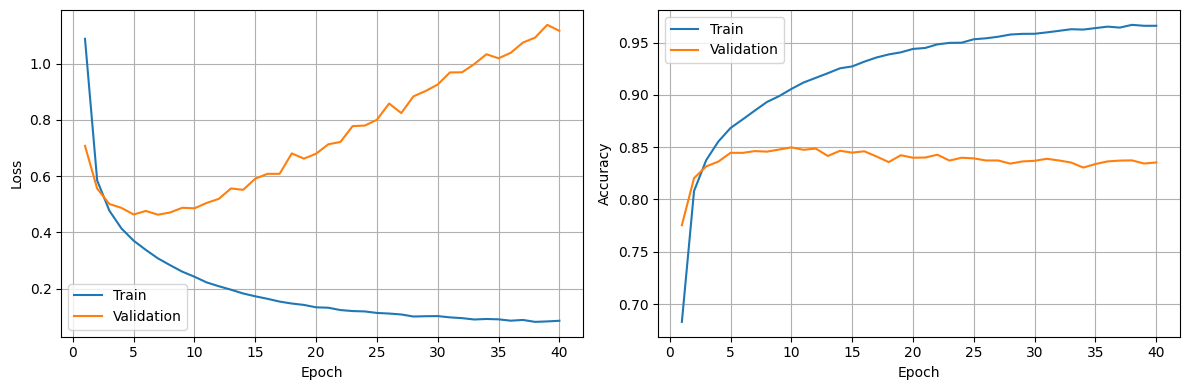

In [94]:
print("\n=== E1: Base MLP (no dropout, no batchnorm) ===")
model = MLP(28*28, [512, 256], 47).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
history, best_val_acc = train_model(model, train_loader, val_loader, optimizer, criterion, device)

plot_history(history)

results.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, no dropout, no BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 40,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history['val_loss'])
})


=== E2: MLP with Dropout (p=0.3) ===
Epoch 1/40: Train Loss=1.2841, Train Acc=0.6254 | Val Loss=0.7289, Val Acc=0.7728
Epoch 2/40: Train Loss=0.7464, Train Acc=0.7614 | Val Loss=0.5742, Val Acc=0.8106
Epoch 3/40: Train Loss=0.6351, Train Acc=0.7916 | Val Loss=0.5194, Val Acc=0.8280
Epoch 4/40: Train Loss=0.5748, Train Acc=0.8070 | Val Loss=0.4982, Val Acc=0.8343
Epoch 5/40: Train Loss=0.5394, Train Acc=0.8181 | Val Loss=0.4742, Val Acc=0.8418
Epoch 6/40: Train Loss=0.5148, Train Acc=0.8236 | Val Loss=0.4683, Val Acc=0.8426
Epoch 7/40: Train Loss=0.4895, Train Acc=0.8305 | Val Loss=0.4521, Val Acc=0.8487
Epoch 8/40: Train Loss=0.4754, Train Acc=0.8346 | Val Loss=0.4443, Val Acc=0.8503
Epoch 9/40: Train Loss=0.4575, Train Acc=0.8396 | Val Loss=0.4381, Val Acc=0.8520
Epoch 10/40: Train Loss=0.4406, Train Acc=0.8434 | Val Loss=0.4438, Val Acc=0.8508
Epoch 11/40: Train Loss=0.4315, Train Acc=0.8452 | Val Loss=0.4381, Val Acc=0.8520
Epoch 12/40: Train Loss=0.4233, Train Acc=0.8469 | Val Los

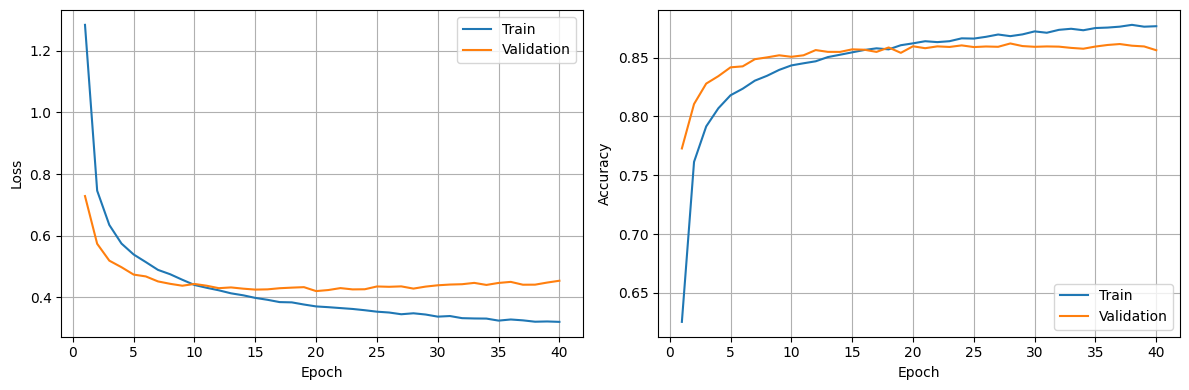

In [95]:
print("\n=== E2: MLP with Dropout (p=0.3) ===")
model = MLP(28*28, [512, 256], 47, dropout_prob=0.3, use_batchnorm=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
history, best_val_acc = train_model(model, train_loader, val_loader, optimizer, criterion, device)

plot_history(history)

results.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 40,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history['val_loss'])
})


=== E3: MLP with BatchNorm ===
Epoch 1/40: Train Loss=0.8491, Train Acc=0.7512 | Val Loss=0.5647, Val Acc=0.8104
Epoch 2/40: Train Loss=0.4892, Train Acc=0.8334 | Val Loss=0.4854, Val Acc=0.8393
Epoch 3/40: Train Loss=0.4104, Train Acc=0.8567 | Val Loss=0.4726, Val Acc=0.8345
Epoch 4/40: Train Loss=0.3630, Train Acc=0.8695 | Val Loss=0.4398, Val Acc=0.8505
Epoch 5/40: Train Loss=0.3256, Train Acc=0.8795 | Val Loss=0.4501, Val Acc=0.8492
Epoch 6/40: Train Loss=0.2958, Train Acc=0.8882 | Val Loss=0.4488, Val Acc=0.8517
Epoch 7/40: Train Loss=0.2763, Train Acc=0.8940 | Val Loss=0.4600, Val Acc=0.8500
Epoch 8/40: Train Loss=0.2536, Train Acc=0.9015 | Val Loss=0.4597, Val Acc=0.8508
Epoch 9/40: Train Loss=0.2369, Train Acc=0.9065 | Val Loss=0.4611, Val Acc=0.8496
Epoch 10/40: Train Loss=0.2201, Train Acc=0.9125 | Val Loss=0.4671, Val Acc=0.8521
Epoch 11/40: Train Loss=0.2073, Train Acc=0.9162 | Val Loss=0.4870, Val Acc=0.8502
Epoch 12/40: Train Loss=0.1960, Train Acc=0.9213 | Val Loss=0.49

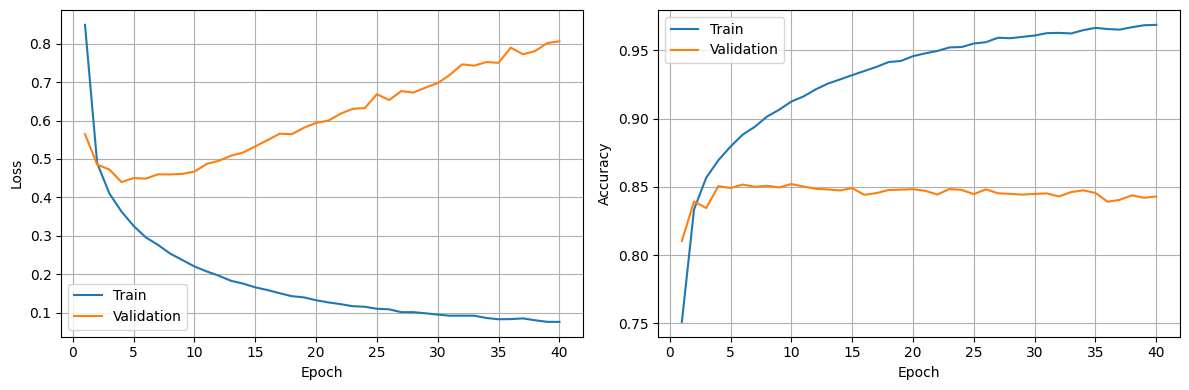

In [96]:
print("\n=== E3: MLP with BatchNorm ===")
model = MLP(28*28, [512, 256], 47, use_batchnorm=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
history, best_val_acc = train_model(model, train_loader, val_loader, optimizer, criterion, device)

plot_history(history)

results.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, BN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 40,
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history['val_loss'])
})

In [97]:
e2_acc = results[-2]['best_val_accuracy']
e3_acc = results[-1]['best_val_accuracy']
best_reg = 'E2' if e2_acc >= e3_acc else 'E3'
print(f"Лучший регуляризатор: {best_reg}")

Лучший регуляризатор: E2



=== E4: Best architecture with Early Stopping ===
Epoch 1/40: Train Loss=1.2810, Train Acc=0.6277 | Val Loss=0.7196, Val Acc=0.7752
Epoch 2/40: Train Loss=0.7418, Train Acc=0.7635 | Val Loss=0.5768, Val Acc=0.8137
Epoch 3/40: Train Loss=0.6317, Train Acc=0.7915 | Val Loss=0.5278, Val Acc=0.8274
Epoch 4/40: Train Loss=0.5743, Train Acc=0.8074 | Val Loss=0.4884, Val Acc=0.8360
Epoch 5/40: Train Loss=0.5370, Train Acc=0.8181 | Val Loss=0.4675, Val Acc=0.8447
Epoch 6/40: Train Loss=0.5140, Train Acc=0.8240 | Val Loss=0.4566, Val Acc=0.8469
Epoch 7/40: Train Loss=0.4876, Train Acc=0.8302 | Val Loss=0.4570, Val Acc=0.8467
Epoch 8/40: Train Loss=0.4732, Train Acc=0.8353 | Val Loss=0.4425, Val Acc=0.8527
Epoch 9/40: Train Loss=0.4535, Train Acc=0.8411 | Val Loss=0.4402, Val Acc=0.8530
Epoch 10/40: Train Loss=0.4425, Train Acc=0.8424 | Val Loss=0.4308, Val Acc=0.8571
Epoch 11/40: Train Loss=0.4357, Train Acc=0.8443 | Val Loss=0.4353, Val Acc=0.8527
Epoch 12/40: Train Loss=0.4199, Train Acc=0.8

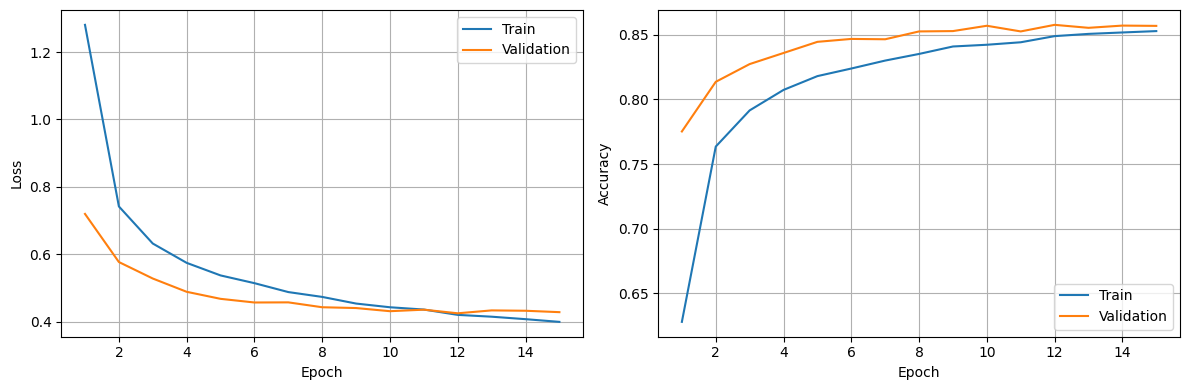

In [99]:
print("\n=== E4: Best architecture with Early Stopping ===")
model = MLP(28*28, [512, 256], 47, dropout_prob=0.3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
history, best_val_acc = train_model(model, train_loader, val_loader, optimizer, criterion, device,
                                    early_stopping_patience=early_stopping_patience)

best_history = history

plot_history(history, save=True)

results.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, dropout=0.3, early_stoping(patience=3)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history['train_loss']),
    'best_val_accuracy': best_val_acc,
    'best_val_loss': min(history['val_loss'])
})

best_model = model
torch.save(best_model.state_dict(), artifacts_dir / 'best_model.pt')

best_config = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': seed,
    'model': {
        'hidden_sizes': [512, 256],
        'activation': 'relu',
        'dropout': 0.3,
        'batchnorm': False
    },
    'optimizer': {
        'name': 'Adam',
        'lr': 1e-3,
        'weight_decay': 0
    },
    'early_stopping_patience': early_stopping_patience
}
with open(artifacts_dir / 'best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)


=== O1: LR too large (1e-1) ===
Epoch 1/6: Train Loss=4.6843, Train Acc=0.0212 | Val Loss=3.8663, Val Acc=0.0212
Epoch 2/6: Train Loss=3.8643, Train Acc=0.0220 | Val Loss=3.8650, Val Acc=0.0223
Epoch 3/6: Train Loss=3.8644, Train Acc=0.0217 | Val Loss=3.8693, Val Acc=0.0216
Epoch 4/6: Train Loss=3.8651, Train Acc=0.0212 | Val Loss=3.8603, Val Acc=0.0205
Epoch 5/6: Train Loss=3.8647, Train Acc=0.0223 | Val Loss=3.8587, Val Acc=0.0211
Epoch 6/6: Train Loss=3.8645, Train Acc=0.0206 | Val Loss=3.8642, Val Acc=0.0220


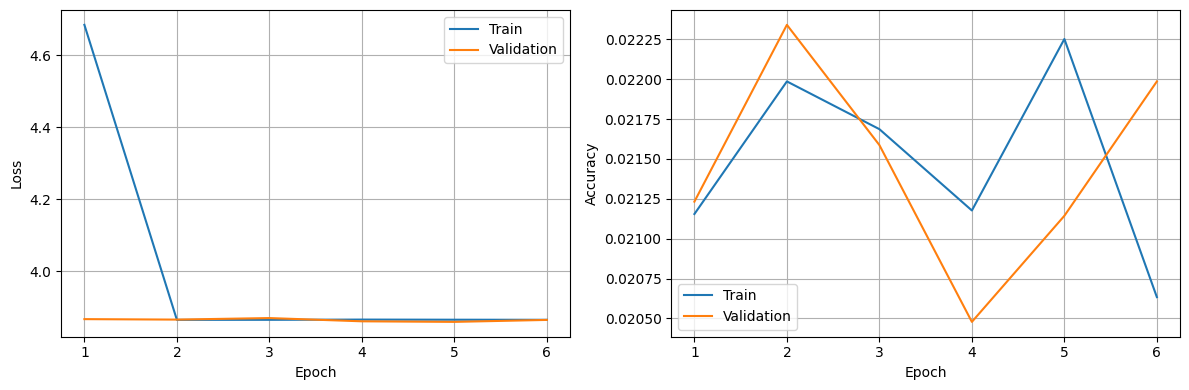


=== O2: LR too small (1e-5) ===
Epoch 1/6: Train Loss=3.7660, Train Acc=0.0786 | Val Loss=3.6062, Val Acc=0.2319
Epoch 2/6: Train Loss=3.3565, Train Acc=0.2368 | Val Loss=3.0034, Val Acc=0.4069
Epoch 3/6: Train Loss=2.7979, Train Acc=0.3325 | Val Loss=2.4495, Val Acc=0.4852
Epoch 4/6: Train Loss=2.4038, Train Acc=0.3888 | Val Loss=2.1020, Val Acc=0.5209
Epoch 5/6: Train Loss=2.1608, Train Acc=0.4278 | Val Loss=1.8881, Val Acc=0.5468
Epoch 6/6: Train Loss=1.9959, Train Acc=0.4594 | Val Loss=1.7462, Val Acc=0.5691


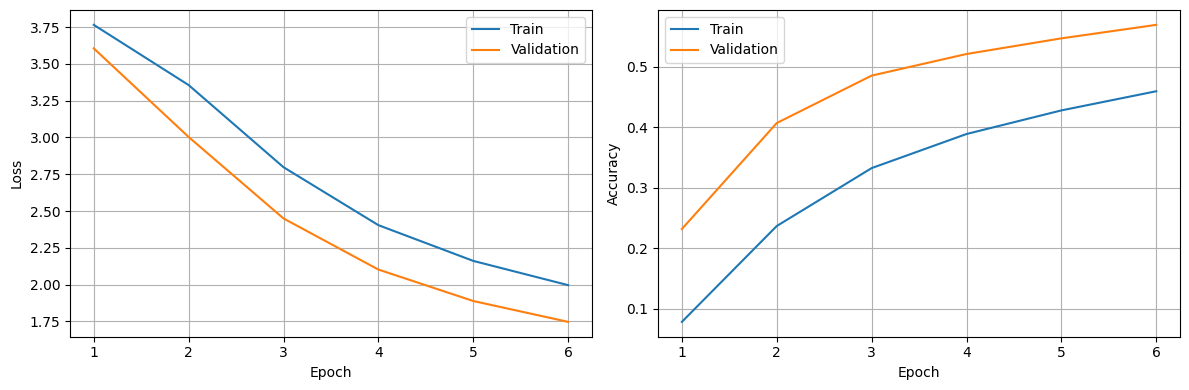

In [103]:
print("\n=== O1: LR too large (1e-1) ===")
model = MLP(28*28, [512, 256], 47, dropout_prob=0.3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-1)
history_large, val_acc_large = train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=6)

plot_history(history_large)

results.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, dropout=0.3)',
    'optimizer': 'Adam',
    'lr': 1e-1,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 6,
    'best_val_accuracy': val_acc_large,
    'best_val_loss': min(history_large['val_loss'])
})

print("\n=== O2: LR too small (1e-5) ===")
model = MLP(28*28, [512, 256], 47, dropout_prob=0.3).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)
history_small, val_acc_small = train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=6)

plot_history(history_small)

results.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, dropout=0.3)',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 6,
    'best_val_accuracy': val_acc_small,
    'best_val_loss': min(history_small['val_loss'])
})


=== O3: SGD with momentum (0.9) and weight decay (1e-4) ===
Epoch 1/15: Train Loss=3.8143, Train Acc=0.0534 | Val Loss=3.7431, Val Acc=0.0988
Epoch 2/15: Train Loss=3.5414, Train Acc=0.1427 | Val Loss=3.1547, Val Acc=0.2935
Epoch 3/15: Train Loss=2.7544, Train Acc=0.3013 | Val Loss=2.2368, Val Acc=0.4674
Epoch 4/15: Train Loss=2.1523, Train Acc=0.4155 | Val Loss=1.7967, Val Acc=0.5429
Epoch 5/15: Train Loss=1.8575, Train Acc=0.4838 | Val Loss=1.5871, Val Acc=0.5764
Epoch 6/15: Train Loss=1.6891, Train Acc=0.5257 | Val Loss=1.4613, Val Acc=0.6013
Epoch 7/15: Train Loss=1.5789, Train Acc=0.5534 | Val Loss=1.3764, Val Acc=0.6227
Epoch 8/15: Train Loss=1.4999, Train Acc=0.5746 | Val Loss=1.3130, Val Acc=0.6370
Epoch 9/15: Train Loss=1.4325, Train Acc=0.5929 | Val Loss=1.2576, Val Acc=0.6520
Epoch 10/15: Train Loss=1.3696, Train Acc=0.6088 | Val Loss=1.2067, Val Acc=0.6640
Epoch 11/15: Train Loss=1.3231, Train Acc=0.6201 | Val Loss=1.1619, Val Acc=0.6742
Epoch 12/15: Train Loss=1.2782, Tra

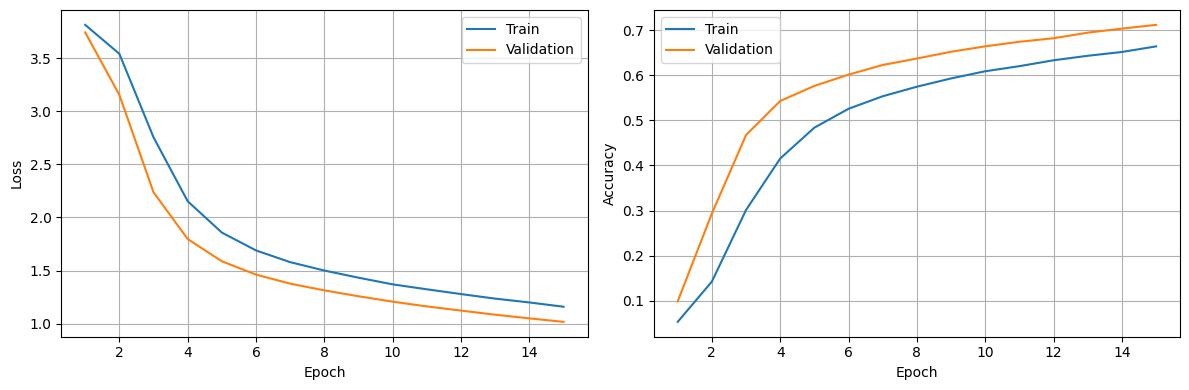

In [104]:
print("\n=== O3: SGD with momentum (0.9) and weight decay (1e-4) ===")
model = MLP(28*28, [512, 256], 47, dropout_prob=0.3).to(device)
optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
history_sgd, val_acc_sgd = train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=15)

plot_history(history_sgd)

results.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': seed,
    'model_summary': 'hidden=[512,256], ReLU, dropout=0.3)',
    'optimizer': 'SGD',
    'lr': 1e-3,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': 15,
    'best_val_accuracy': val_acc_sgd,
    'best_val_loss': min(history_sgd['val_loss'])
})

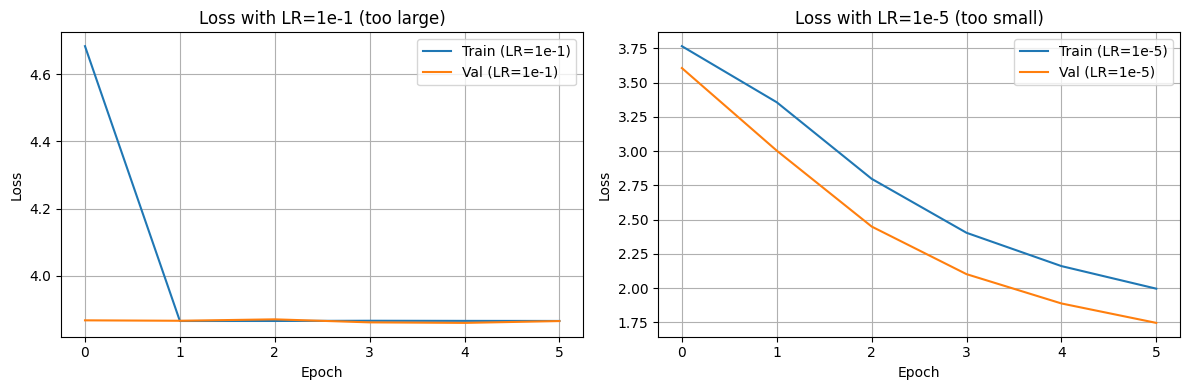

In [105]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_large['train_loss'], label='Train (LR=1e-1)')
plt.plot(history_large['val_loss'], label='Val (LR=1e-1)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss with LR=1e-1 (too large)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_small['train_loss'], label='Train (LR=1e-5)')
plt.plot(history_small['val_loss'], label='Val (LR=1e-5)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss with LR=1e-5 (too small)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(figures_dir / 'curves_lr_extremes.png', dpi=150)
plt.show()

In [106]:
df = pd.DataFrame(results)
cols = ['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr', 'momentum', 'weight_decay',
        'epochs_trained', 'best_val_accuracy', 'best_val_loss']
df = df[cols]
df.to_csv(artifacts_dir / 'runs.csv', index=False)
print("Results saved to artifacts/runs.csv")
df

Results saved to artifacts/runs.csv


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"hidden=[512,256], ReLU, no dropout, no BN",Adam,0.00100,,0.0000,40,0.849778,0.462538
1,E2,EMNIST,42,"hidden=[512,256], ReLU, dropout=0.3",Adam,0.00100,,0.0000,40,0.862101,0.420724
2,E3,EMNIST,42,"hidden=[512,256], ReLU, BN",Adam,0.00100,,0.0000,40,0.852083,0.439800
3,E4,EMNIST,42,"hidden=[512,256], ReLU, dropout=0.3, early_sto...",Adam,0.00100,,0.0000,15,0.857846,0.424570
4,O1,EMNIST,42,"hidden=[512,256], ReLU, dropout=0.3)",Adam,0.10000,,0.0000,6,0.022340,3.858729
5,O2,EMNIST,42,"hidden=[512,256], ReLU, dropout=0.3)",Adam,0.00001,,0.0000,6,0.569060,1.746242
6,O3,EMNIST,42,"hidden=[512,256], ReLU, dropout=0.3)",SGD,0.00100,0.9,0.0001,15,0.711658,1.016385


In [107]:
# Загружаем лучшую модель (E4)
best_model.load_state_dict(torch.load(artifacts_dir / 'best_model.pt'))
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Final test accuracy of best model (E4): {test_acc:.4f}")
print(f"Final test loss: {test_loss:.4f}")

Final test accuracy of best model (E4): 0.8539
Final test loss: 0.4457
